# 🧠 MAE Pretraining for Medical Image Segmentation
## BraTS Edition — ResUNet Fine-tuning

Complete pipeline: **ResNet-MAE SSL on BraTS MRI** → **ResUNet fine-tuning** (encoder weights transferred; ImageNet ablation optional).

> ⚠️ **BraTS data is required.** If the dataset cannot be loaded the notebook raises an error and stops — no synthetic fallback is used.

**Pipeline:**
1. 📦 Environment Setup & Imports
2. ⚙️ Configuration
3. 🗂️ Dataset Loading — BraTS only
4. 🔄 Medical Augmentations
5. 🟠 MAE Pretraining
6. 🎯 ResUNet Fine-Tuning (ResNet34 Encoder + U-Net Decoder)
7. 📊 Evaluation (Dice, IoU, Hausdorff)
8. 📈 Results & Visualizations


---
## 1. 📦 Environment Setup & Imports

In [ ]:
# Install required packages (run once)
import subprocess, sys

packages = [
    'torch', 'torchvision', 'timm',
    'nibabel',
    'scipy',
    'scikit-learn',
    'pyyaml',
    'matplotlib',
    'numpy',
    'tqdm',
    'einops',
    'monai',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')


In [ ]:
# ── Core imports ─────────────────────────────────────────────────────────────
import os, math, copy, random, yaml, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms

# ── Medical imaging ──────────────────────────────────────────────────────────
import nibabel as nib

# ── Timm / einops ────────────────────────────────────────────────────────────
import timm
from einops import rearrange, repeat

# ── MONAI ────────────────────────────────────────────────────────────────────
try:
    from monai.transforms import (
        RandGaussianNoise, RandBiasField, RandGibbsNoise,
        RandKSpaceSpikeNoise, NormalizeIntensity, ScaleIntensityRange
    )
    MONAI_AVAILABLE = True
except ImportError:
    MONAI_AVAILABLE = False
    print('⚠️  MONAI not available — using custom augmentations.')

warnings.filterwarnings('ignore')

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')

# ── Reproducibility ──────────────────────────────────────────────────────────
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
torch.backends.cudnn.benchmark = True
print('✅ Imports done.')


---
## 2. ⚙️ Configuration

In [ ]:
MAE_CONFIG_YAML = """
model:
  backbone: resnet34_mae       # SSL backbone aligned with ResUNet encoder
  backbone_legacy: vit_base_patch16
  image_size: 224
  patch_size: 16
  embed_dim: 768
  encoder_depth: 12
  encoder_heads: 12
  decoder_embed_dim: 512
  decoder_depth: 8
  decoder_heads: 16
  mask_ratio: 0.75
  patch_size: 16

training:
  epochs: 10
  batch_size: 32
  learning_rate: 1.5e-4
  weight_decay: 0.05
  warmup_epochs: 1
  optimizer: adamw
  scheduler: cosine

data:
  image_size: 224
  in_channels: 1
  num_workers: 2
"""

FINETUNE_CONFIG_YAML = """
model:
  encoder: resnet34         # ResNet34 encoder backbone
  num_classes: 4            # BraTS: BG=0, NCR=1, ED=2, ET=3

training:
  epochs: 10
  batch_size: 8
  learning_rate: 1.0e-4
  encoder_lr_scale: 0.1           # full-data (>= 50% labels) after decoder warmup
  encoder_lr_scale_fewshot: 1.0   # few-shot: full encoder LR once unfrozen
  freeze_encoder_epochs: 3        # decoder-only warmup (stabilize decoder first)
  few_shot_seeds: [42, 123, 456, 789, 2024]  # patient-level subsample seeds
  weight_decay: 1.0e-5
  loss: dice_ce
  label_fractions: [0.05, 1.0]

ssl:
  checkpoint: resnet_mae_pretrained.pth
  default_encoder_init: ssl        # ssl | imagenet | random
"""

# ── BraTS root — update to your local BraTS folder ───────────────────────────
#
#  Expected layout (BraTS 2020/2021/2023):
#    BRATS_ROOT/
#      BraTS20_Training_001/
#        BraTS20_Training_001_t1.nii.gz
#        BraTS20_Training_001_t1ce.nii.gz
#        BraTS20_Training_001_t2.nii.gz
#        BraTS20_Training_001_flair.nii.gz
#        BraTS20_Training_001_seg.nii.gz
#      BraTS20_Training_002/ ...
#
BRATS_ROOT = 'data'   # ← set to your BraTS directory

BRATS_MODALITIES   = ['t1n', 't1c', 't2w', 't2f']
BRATS_SEG_MODALITY = 't2f'

def load_config(yaml_str: str) -> dict:
    return yaml.safe_load(yaml_str)

mae_cfg      = load_config(MAE_CONFIG_YAML)
finetune_cfg = load_config(FINETUNE_CONFIG_YAML)

print('✅ Configs loaded.')
print('MAE backbone:     ', mae_cfg['model']['backbone'])
print('MAE mask ratio:   ', mae_cfg['model']['mask_ratio'])
print('Fine-tune encoder:', finetune_cfg['model']['encoder'])
print('Fine-tune classes:', finetune_cfg['model']['num_classes'])
print('MAE epochs:       ', mae_cfg['training']['epochs'])
print('Fine-tune epochs: ', finetune_cfg['training']['epochs'])
print('Freeze encoder:   ', finetune_cfg['training']['freeze_encoder_epochs'], 'epochs (decoder-first)')
print('Few-shot seeds:   ', finetune_cfg['training']['few_shot_seeds'])
print('SSL checkpoint:   ', finetune_cfg['ssl']['checkpoint'])
print(f'BraTS root:        {BRATS_ROOT}')


---
## 3. 🗂️ Dataset Loading — BraTS Only

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Dataset Loading — BraTS NIfTI ONLY
#  If BraTS data cannot be found, a clear RuntimeError is raised.
#  No synthetic fallback is used.
# ─────────────────────────────────────────────────────────────────────────────

def load_nifti_volume(path: str) -> np.ndarray:
    """Load a NIfTI file and return a float32 array (H, W, D)."""
    return nib.load(path).get_fdata(dtype=np.float32)


def normalize_volume(vol: np.ndarray,
                      clip_percentile: Tuple[float, float] = (0.5, 99.5)) -> np.ndarray:
    """Clip outliers and rescale to [0, 1]."""
    if vol.size == 0:
        raise ValueError('Empty volume — check NIfTI file integrity.')
    lo, hi = np.percentile(vol, clip_percentile)
    return np.clip((vol - lo) / (hi - lo + 1e-8), 0.0, 1.0)


# ── BraTS directory scanner ───────────────────────────────────────────────────

def scan_brats_directory(
    brats_root: str,
    modalities: List[str] = BRATS_MODALITIES,
    seg_modality: str = BRATS_SEG_MODALITY,
) -> Tuple[List[str], List[Tuple[str, str]]]:
    """
    Walk BRATS_ROOT and collect:
      unlabeled_paths : all modality NIfTI paths (for MAE pretraining)
      labeled_pairs   : (image_path, mask_path) pairs (for fine-tuning)
    Raises RuntimeError if no data is found.
    """
    root = Path(brats_root)
    if not root.is_dir():
        raise RuntimeError(
            f"❌ BraTS root not found: '{brats_root}'.\n"
            "   Set BRATS_ROOT to the folder containing BraTS case sub-directories."
        )

    unlabeled, labeled = [], []

    for case_dir in sorted(root.iterdir()):
        if not case_dir.is_dir():
            continue
        case = case_dir.name

        for mod in modalities:
            for ext in [f'_{mod}.nii.gz', f'_{mod}.nii', f'-{mod}.nii.gz', f'-{mod}.nii']:
                p = case_dir / (case + ext)
                if p.exists():
                    unlabeled.append(str(p))
                    break

        img_path = seg_path = None
        for ext in [f'_{seg_modality}.nii.gz', f'_{seg_modality}.nii',
                    f'-{seg_modality}.nii.gz', f'-{seg_modality}.nii']:
            p = case_dir / (case + ext)
            if p.exists():
                img_path = str(p); break
        for ext in ['_seg.nii.gz', '_seg.nii', '-seg.nii.gz', '-seg.nii']:
            p = case_dir / (case + ext)
            if p.exists():
                seg_path = str(p); break
        if img_path and seg_path:
            labeled.append((img_path, seg_path))

    if len(unlabeled) == 0:
        raise RuntimeError(
            f"❌ No BraTS NIfTI volumes found under '{brats_root}'.\n"
            "   Verify the path and that files match the expected naming convention."
        )
    if len(labeled) == 0:
        raise RuntimeError(
            f"❌ No BraTS labeled (image+mask) pairs found under '{brats_root}'.\n"
            "   Segmentation masks must end with '_seg.nii' or '_seg.nii.gz'."
        )

    print(f'🔍 BraTS scan: {len(unlabeled)} modality volumes, {len(labeled)} labeled pairs.')
    return unlabeled, labeled


# ── Unlabeled dataset (MAE pretraining) ───────────────────────────────────────

class BraTSUnlabeledDataset(Dataset):
    """Axial 2-D slices from BraTS volumes for MAE pretraining (no masks needed)."""

    def __init__(self, scan_paths: List[str], image_size: int = 224,
                 min_foreground_ratio: float = 0.05, transform=None):
        self.image_size = image_size
        self.transform  = transform
        self.slices: List[Tuple[str, int]] = []

        print(f'🔍 Indexing {len(scan_paths)} NIfTI files for pretraining …')
        for path in tqdm(scan_paths):
            try:
                vol = normalize_volume(load_nifti_volume(path))
                for z in range(vol.shape[-1]):
                    if vol[..., z].mean() > min_foreground_ratio:
                        self.slices.append((path, z))
            except Exception as e:
                print(f'  ⚠️  Skipping {path}: {e}')

        if len(self.slices) == 0:
            raise RuntimeError('❌ No usable slices found in BraTS unlabeled set.')
        print(f'✅ Pretraining slices: {len(self.slices):,}')

    def __len__(self) -> int: return len(self.slices)

    def __getitem__(self, idx: int) -> torch.Tensor:
        path, z = self.slices[idx]
        sl = normalize_volume(load_nifti_volume(path))[..., z].astype(np.float32)
        t  = F.interpolate(
            torch.from_numpy(sl).unsqueeze(0).unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode='bilinear', align_corners=False).squeeze(0)
        return self.transform(t) if self.transform else t


# ── Labeled dataset (fine-tuning) ─────────────────────────────────────────────

class BraTSLabeledDataset(Dataset):
    """
    BraTS image + segmentation mask pairs.
    4 classes: 0=BG, 1=NCR, 2=ED, 3=ET.
    BraTS 2020 label 4 is remapped to 3.
    """

    def __init__(self, scan_label_pairs: List[Tuple[str, str]],
                 image_size: int = 224, augment: bool = True):
        self.pairs      = scan_label_pairs
        self.image_size = image_size
        self.augment    = augment
        self.index: List[Tuple[int, int]] = []

        print(f'🔍 Indexing {len(scan_label_pairs)} labeled cases …')
        for pi, (img_path, _) in enumerate(tqdm(scan_label_pairs)):
            try:
                vol = load_nifti_volume(img_path)
                self.index += [(pi, z) for z in range(vol.shape[-1])]
            except Exception as e:
                print(f'  ⚠️  Skipping {img_path}: {e}')

        if len(self.index) == 0:
            raise RuntimeError('❌ No usable slices found in BraTS labeled set.')
        print(f'✅ Labeled slices: {len(self.index):,}')

    def _remap_labels(self, mask: np.ndarray) -> np.ndarray:
        out = mask.copy(); out[mask == 4] = 3; return out

    def __len__(self) -> int: return len(self.index)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        pi, z = self.index[idx]
        img_path, msk_path = self.pairs[pi]

        img_sl = normalize_volume(load_nifti_volume(img_path))[..., z].astype(np.float32)
        msk_sl = self._remap_labels(load_nifti_volume(msk_path).astype(np.int64))[..., z]

        img_t = F.interpolate(
            torch.from_numpy(img_sl).unsqueeze(0).unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode='bilinear', align_corners=False).squeeze(0)
        msk_t = F.interpolate(
            torch.from_numpy(msk_sl).float().unsqueeze(0).unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode='nearest').squeeze().long()

        if self.augment:
            img_t, msk_t = self._augment(img_t, msk_t)
        return img_t, msk_t

    @staticmethod
    def _augment(img, msk):
        if random.random() > 0.5: img = torch.flip(img, [-1]); msk = torch.flip(msk, [-1])
        if random.random() > 0.5: img = torch.flip(img, [-2]); msk = torch.flip(msk, [-2])
        if random.random() > 0.5: img = (img + torch.randn_like(img) * 0.02).clamp(0., 1.)
        return img, msk


# ── Build datasets (BraTS only) ───────────────────────────────────────────────

def build_datasets(
    brats_root: str,
    image_size: int = 224,
    val_split: float = 0.2,
    seed: int = 42,
) -> Tuple[Dataset, Dataset, Dataset]:
    """
    Returns (pretrain_dataset, train_labeled_dataset, val_labeled_dataset).
    Raises RuntimeError immediately if BraTS data is unavailable.
    """
    unlabeled_paths, labeled_pairs = scan_brats_directory(brats_root)

    pretrain_ds = BraTSUnlabeledDataset(unlabeled_paths, image_size=image_size)

    # Split by patient/case (not random slices) to avoid train/val leakage
    rng = random.Random(seed)
    case_ids = list(range(len(labeled_pairs)))
    rng.shuffle(case_ids)
    n_val_cases = max(1, int(len(labeled_pairs) * val_split))
    val_case_ids   = case_ids[:n_val_cases]
    train_case_ids = case_ids[n_val_cases:]
    train_pairs = [labeled_pairs[i] for i in train_case_ids]
    val_pairs   = [labeled_pairs[i] for i in val_case_ids]

    train_ds = BraTSLabeledDataset(train_pairs, image_size=image_size, augment=True)
    val_ds   = BraTSLabeledDataset(val_pairs,   image_size=image_size, augment=False)

    print(f'\n📦 Dataset summary')
    print(f'   Pretrain (unlabeled): {len(pretrain_ds):,} slices')
    print(f'   Fine-tune train     : {len(train_ds):,} slices ({len(train_pairs)} cases)')
    print(f'   Fine-tune val       : {len(val_ds):,} slices ({len(val_pairs)} cases)')
    return pretrain_ds, train_ds, val_ds


# ── Load (raises an error if BraTS is not available) ──────────────────────────
pretrain_ds, train_ds, val_ds = build_datasets(
    brats_root = BRATS_ROOT,
    image_size = mae_cfg['data']['image_size'],
)

sample = pretrain_ds[0]
print(f'\n✅ Pretrain sample shape : {sample.shape}')
img_s, msk_s = train_ds[0]
print(f'   Labeled image shape  : {img_s.shape}')
print(f'   Labeled mask shape   : {msk_s.shape}, classes: {msk_s.unique().tolist()}')


---
## 4. 🔄 Medical-Specific Augmentations (MAE-compatible)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Medical-domain augmentations for MAE pretraining (brain MRI)
# ─────────────────────────────────────────────────────────────────────────────

class GaussianNoise(nn.Module):
    def __init__(self, std: float = 0.05): super().__init__(); self.std = std
    def forward(self, x): return (x + torch.randn_like(x) * self.std).clamp(0., 1.)


class RandomGammaCorrection(nn.Module):
    def __init__(self, gamma_range=(0.7, 1.5)): super().__init__(); self.lo, self.hi = gamma_range
    def forward(self, x): return x.clamp(1e-8, 1.).pow(random.uniform(self.lo, self.hi))


class RandomIntensityShift(nn.Module):
    def __init__(self, shift=0.1, scale=0.1): super().__init__(); self.shift=shift; self.scale=scale
    def forward(self, x):
        a = 1. + random.uniform(-self.scale, self.scale)
        b = random.uniform(-self.shift, self.shift)
        return (a * x + b).clamp(0., 1.)


class RandomElasticDeformation(nn.Module):
    def __init__(self, alpha=50., sigma=5.): super().__init__(); self.alpha=alpha; self.sigma=sigma
    def forward(self, x):
        _, H, W = x.shape
        dx = torch.randn(1,1,H,W)*self.alpha; dy = torch.randn(1,1,H,W)*self.alpha
        k  = max(3, int(self.sigma)*2+1)
        dx = F.avg_pool2d(dx, k, 1, k//2); dy = F.avg_pool2d(dy, k, 1, k//2)
        gy, gx = torch.meshgrid(torch.linspace(-1,1,H), torch.linspace(-1,1,W), indexing='ij')
        grid = torch.stack([gx,gy],-1).unsqueeze(0)
        grid[...,0] += dx.squeeze(1)/W; grid[...,1] += dy.squeeze(1)/H
        return F.grid_sample(x.unsqueeze(0), grid.clamp(-1,1),
                             mode='bilinear', padding_mode='reflection',
                             align_corners=True).squeeze(0)


class RandomGhosting(nn.Module):
    def __init__(self, intensity=0.3, n_ghosts=3): super().__init__(); self.intensity=intensity; self.n=n_ghosts
    def forward(self, x):
        if random.random() < 0.5:
            shift = x.shape[-2]//(self.n+1)
            for i in range(1, self.n+1):
                x = (x + self.intensity/i * torch.roll(x.clone(), i*shift, -2)).clamp(0.,1.)
        return x


def get_mae_augmentation() -> nn.Sequential:
    return nn.Sequential(
        RandomGammaCorrection(gamma_range=(0.8, 1.3)),
        RandomIntensityShift(shift=0.05, scale=0.05),
        GaussianNoise(std=0.02),
        RandomGhosting(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
    )


class AugmentedDataset(Dataset):
    """Wraps an unlabeled dataset with an augmentation pipeline."""
    def __init__(self, base_dataset, augmentation):
        self.ds = base_dataset; self.aug = augmentation
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx): return self.aug(self.ds[idx])


aug_pipeline = get_mae_augmentation()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('MAE Augmentation Examples — Brain MRI (BraTS)\nRow 1: Original  |  Row 2: Augmented',
             fontsize=12, fontweight='bold')
for col in range(5):
    raw = pretrain_ds[col]
    aug = aug_pipeline(raw)
    axes[0, col].imshow(raw.squeeze().numpy(), cmap='gray'); axes[0, col].set_title(f'Original #{col}', fontsize=9); axes[0, col].axis('off')
    axes[1, col].imshow(aug.squeeze().numpy(), cmap='gray'); axes[1, col].set_title(f'Augmented #{col}', fontsize=9); axes[1, col].axis('off')
plt.tight_layout(); plt.show()
print('✅ Augmentations defined.')


---
## 5. 🟠 ResNet-MAE — BraTS SSL (encoder weights → ResUNet)

In [16]:
import math
from torch.optim.lr_scheduler import LambdaLR

def cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / max(1, warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)

# ─────────────────────────────────────────────────────────────────────────────
#  ResNet-MAE on BraTS MRI (encoder aligned with ResUNet — weights transfer)
# ─────────────────────────────────────────────────────────────────────────────

def create_resnet34_encoder(in_chans: int = 1, pretrained: bool = False) -> nn.Module:
    """Shared timm ResNet34 feature encoder for ResNet-MAE and ResUNet."""
    backbone = timm.create_model(
        'resnet34', pretrained=pretrained,
        features_only=True, out_indices=(0, 1, 2, 3, 4),
    )
    if in_chans != 3:
        old_conv = backbone.conv1
        new_conv = nn.Conv2d(in_chans, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            if pretrained and old_conv.weight.shape[1] == 3:
                new_conv.weight.copy_(
                    old_conv.weight.mean(dim=1, keepdim=True).expand(-1, in_chans, -1, -1)
                    / in_chans)
            else:
                nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
        backbone.conv1 = new_conv
    return backbone


def load_ssl_encoder_weights(encoder: nn.Module, checkpoint_path: str):
    """Load BraTS ResNet-MAE encoder into ResUNet.encoder."""
    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(
            f'SSL checkpoint not found: {checkpoint_path}. Run ResNet-MAE pretraining first.')
    ckpt  = torch.load(checkpoint_path, map_location='cpu')
    state = ckpt['encoder_state'] if isinstance(ckpt, dict) and 'encoder_state' in ckpt else ckpt
    return encoder.load_state_dict(state, strict=False)


class ResNetMAEDecoder(nn.Module):
    def __init__(self, out_ch: int = 1):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.Conv2d(16, out_ch, 3, padding=1),
        )
    def forward(self, x): return self.net(x)


class ResNetMaskedAutoEncoder(nn.Module):
    """Patch-masked MAE; encoder is identical to ResUNet.encoder."""
    def __init__(self, img_size=224, patch_size=16, in_chans=1,
                 mask_ratio=0.75, pretrained_encoder=False):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.in_chans   = in_chans
        self.encoder    = create_resnet34_encoder(in_chans, pretrained=pretrained_encoder)
        self.decoder    = ResNetMAEDecoder(out_ch=in_chans)
        self.grid       = img_size // patch_size

    def random_mask(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        B, C, H, W = x.shape
        gh = gw = self.grid
        n_patch = gh * gw
        n_mask  = int(n_patch * self.mask_ratio)
        patch_mask = torch.zeros(B, n_patch, device=x.device, dtype=torch.bool)
        for b in range(B):
            patch_mask[b, torch.randperm(n_patch, device=x.device)[:n_mask]] = True
        mask_2d  = patch_mask.view(B, 1, gh, gw).float()
        mask_full = F.interpolate(mask_2d, size=(H, W), mode='nearest')
        return x * (1.0 - mask_full), mask_full

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x_masked, mask_full = self.random_mask(x)
        bottleneck = self.encoder(x_masked)[-1]
        recon = self.decoder(bottleneck)
        if recon.shape[-2:] != x.shape[-2:]:
            recon = F.interpolate(recon, size=x.shape[-2:], mode='bilinear', align_corners=False)
        loss_map = ((recon - x) ** 2) * mask_full
        denom = mask_full.sum().clamp_min(1.0) * x.shape[1]
        return loss_map.sum() / denom, recon


def pretrain_resnet_mae(cfg: dict, unlabeled_dataset: Dataset,
                        save_path: str = 'resnet_mae_pretrained.pth',
                        max_epochs: Optional[int] = None,
                        pretrained_encoder: bool = False) -> Tuple[nn.Module, List[float]]:
    """Self-supervised ResNet-MAE on unlabeled BraTS slices (no ImageNet)."""
    tcfg   = cfg['training']
    mcfg   = cfg['model']
    epochs = max_epochs or tcfg['epochs']
    in_ch  = cfg['data']['in_channels']
    loader = DataLoader(unlabeled_dataset, batch_size=tcfg['batch_size'],
                        shuffle=True, num_workers=0, drop_last=True,
                        pin_memory=DEVICE.type == 'cuda')
    model = ResNetMaskedAutoEncoder(
        img_size=mcfg.get('image_size', cfg['data']['image_size']),
        patch_size=mcfg.get('patch_size', 16),
        in_chans=in_ch,
        mask_ratio=mcfg['mask_ratio'],
        pretrained_encoder=pretrained_encoder,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=tcfg['learning_rate'],
                                  weight_decay=tcfg['weight_decay'], betas=(0.9, 0.95))
    scheduler = cosine_schedule_with_warmup(optimizer, tcfg['warmup_epochs'], epochs)
    loss_history = []
    print(f'\n🟠 ResNet-MAE (BraTS SSL)  [{epochs} epochs, {len(unlabeled_dataset):,} samples]')
    print(f'   Encoder: ResNet34 (ImageNet init={pretrained_encoder}) → saved for ResUNet')
    epoch_bar = tqdm(range(epochs), desc='ResNet-MAE', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        epoch_loss = 0.
        for imgs in loader:
            imgs = imgs.to(DEVICE)
            loss, _ = model(imgs)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        avg = epoch_loss / len(loader)
        loss_history.append(avg)
        epoch_bar.set_postfix(avg_loss=f'{avg:.4f}')
        print(f'  ✅ Epoch {epoch+1:>2}/{epochs}  avg_loss={avg:.4f}')
    torch.save({'encoder_state': model.encoder.state_dict(), 'config': cfg,
                'type': 'resnet_mae'}, save_path)
    print(f'\n✅ ResNet-MAE encoder saved → {save_path}')
    return model, loss_history


# ─────────────────────────────────────────────────────────────────────────────
#  Legacy ViT-MAE (not used for ResUNet weight transfer — kept for reference)
# ─────────────────────────────────────────────────────────────────────────────

# ── Patch embedding ──────────────────────────────────────────────────────────

class PatchEmbed(nn.Module):
    """Split image into patches and project to embedding dim."""
    def __init__(self, img_size=224, patch_size=16, in_chans=1, embed_dim=768):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, patch_size, patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)  →  (B, N, D)
        x = self.proj(x)                       # (B, D, H/P, W/P)
        x = x.flatten(2).transpose(1, 2).contiguous()  # (B, N, D)
        return x


# ── Sinusoidal 2-D positional encoding ───────────────────────────────────────

def get_2d_sincos_pos_embed(embed_dim: int, grid_size: int) -> np.ndarray:
    """
    Generate 2D sinusoidal positional embeddings.
    Returns: (grid_size**2, embed_dim)
    """
    g = np.arange(grid_size, dtype=np.float32)
    grid_h, grid_w = np.meshgrid(g, g, indexing='ij')
    grid = np.stack([grid_h, grid_w], axis=0)   # (2, G, G)

    assert embed_dim % 4 == 0
    half  = embed_dim // 4
    omega = np.arange(half, dtype=np.float32) / half
    omega = 1. / (10000 ** omega)               # (half,)

    def sincos(coords):
        c = coords.reshape(-1)[:, None] * omega[None, :]  # (N, half)
        return np.concatenate([np.sin(c), np.cos(c)], axis=1)  # (N, embed_dim//2)

    emb_h = sincos(grid[0])
    emb_w = sincos(grid[1])
    return np.concatenate([emb_h, emb_w], axis=1)   # (N, embed_dim)


# ── MAE Encoder (ViT) ─────────────────────────────────────────────────────────

class MAEEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=1,
                 embed_dim=768, depth=12, num_heads=12):
        super().__init__()
        self.patch_embed  = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches

        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Fixed sinusoidal positional embedding
        pos = get_2d_sincos_pos_embed(embed_dim, img_size // patch_size)
        pos = np.concatenate([np.zeros((1, embed_dim)), pos], axis=0)  # +CLS
        self.register_buffer('pos_embed',
                             torch.from_numpy(pos).float().unsqueeze(0))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.0, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x: torch.Tensor, mask_ratio: float = 0.75
                ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
          latent   : (B, N_visible+1, D)  — visible patch tokens + CLS
          mask     : (B, N)               — bool, True = masked
          ids_restore: (B, N)             — indices to restore original order
        """
        B       = x.size(0)
        tokens  = self.patch_embed(x)           # (B, N, D)
        N       = tokens.size(1)

        # Add positional embedding (skip CLS slot)
        tokens  = tokens + self.pos_embed[:, 1:, :]

        # ── Random masking ──────────────────────────────────────────────────
        n_mask   = int(N * mask_ratio)
        noise    = torch.rand(B, N, device=x.device)
        ids_sort = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_sort, dim=1)

        ids_keep = ids_sort[:, :N - n_mask]
        tokens   = torch.gather(tokens, 1,
                                ids_keep.unsqueeze(-1).expand(-1, -1, tokens.size(-1)))

        mask = torch.ones(B, N, device=x.device, dtype=torch.bool)
        mask.scatter_(1, ids_keep, False)       # False = visible

        # Prepend CLS token
        cls  = self.cls_token.expand(B, -1, -1) + self.pos_embed[:, :1, :]
        tokens = torch.cat([cls, tokens], dim=1)

        latent = self.norm(self.transformer(tokens))
        return latent, mask, ids_restore


# ── MAE Decoder ───────────────────────────────────────────────────────────────

class MAEDecoder(nn.Module):
    def __init__(self, num_patches, encoder_dim=768, decoder_dim=512,
                 depth=8, num_heads=16, patch_size=16, in_chans=1):
        super().__init__()
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token    = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        pos = get_2d_sincos_pos_embed(decoder_dim,
                                       int(num_patches ** 0.5))
        pos = np.concatenate([np.zeros((1, decoder_dim)), pos], axis=0)
        self.register_buffer('decoder_pos',
                             torch.from_numpy(pos).float().unsqueeze(0))

        layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=num_heads,
            dim_feedforward=decoder_dim * 4,
            dropout=0.0, batch_first=True, norm_first=True)
        self.transformer   = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm          = nn.LayerNorm(decoder_dim)
        self.pred          = nn.Linear(decoder_dim,
                                       patch_size * patch_size * in_chans)

    def forward(self, latent: torch.Tensor,
                ids_restore: torch.Tensor) -> torch.Tensor:
        B   = latent.size(0)
        x   = self.decoder_embed(latent)        # (B, N_vis+1, D_dec)

        # Fill in mask tokens
        n_mask = ids_restore.size(1) - (latent.size(1) - 1)  # exclude CLS
        mask_tokens = self.mask_token.expand(B, n_mask, -1)
        x_no_cls    = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # (B,N,D)
        x_no_cls    = torch.gather(x_no_cls, 1,
                                   ids_restore.unsqueeze(-1).expand(-1, -1, x.size(-1)))
        x = torch.cat([x[:, :1, :], x_no_cls], dim=1)  # re-add CLS

        x = x + self.decoder_pos
        x = self.norm(self.transformer(x))
        return self.pred(x[:, 1:, :])           # (B, N, patch_size^2 * C)


# ── Full MAE model ─────────────────────────────────────────────────────────────

class MaskedAutoEncoder(nn.Module):
    def __init__(self, cfg: dict):
        super().__init__()
        m = cfg['model']
        self.mask_ratio = m['mask_ratio']
        self.patch_size = m['patch_size']
        self.in_chans   = cfg['data']['in_channels']
        n_patches = (m['image_size'] // m['patch_size']) ** 2

        self.encoder = MAEEncoder(
            img_size   = m['image_size'],
            patch_size = m['patch_size'],
            in_chans   = self.in_chans,
            embed_dim  = m['embed_dim'],
            depth      = m['encoder_depth'],
            num_heads  = m['encoder_heads'],
        )
        self.decoder = MAEDecoder(
            num_patches      = n_patches,
            encoder_dim      = m['embed_dim'],
            decoder_dim      = m['decoder_embed_dim'],
            depth            = m['decoder_depth'],
            num_heads        = m['decoder_heads'],
            patch_size       = m['patch_size'],
            in_chans         = self.in_chans,
        )

    def patchify(self, x: torch.Tensor) -> torch.Tensor:
        """(B, C, H, W) → (B, N, patch_size^2 * C)"""
        p = self.patch_size
        B, C, H, W = x.shape
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).contiguous()  # (B, H/p, W/p, p, p, C)
        x = x.reshape(B, (H // p) * (W // p), p * p * C)
        return x

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        latent, mask, ids_restore = self.encoder(x, self.mask_ratio)
        pred  = self.decoder(latent, ids_restore)   # (B, N, D)
        target = self.patchify(x)                    # (B, N, D)
        # Normalize target patches (stabilises training)
        mean  = target.mean(dim=-1, keepdim=True)
        var   = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()
        # MSE on masked patches only
        loss  = ((pred - target) ** 2).mean(dim=-1)
        loss  = (loss * mask).sum() / mask.sum()
        return loss, pred


# ── MAE training loop ─────────────────────────────────────────────────────────

def pretrain_mae(cfg: dict,
                 unlabeled_dataset: Dataset,
                 save_path: str = 'mae_pretrained.pth',
                 max_epochs: Optional[int] = None) -> Tuple[MaskedAutoEncoder, List[float]]:
    tcfg   = cfg['training']
    epochs = max_epochs or tcfg['epochs']

    loader = DataLoader(unlabeled_dataset,
                        batch_size=tcfg['batch_size'],
                        shuffle=True, num_workers=0, drop_last=True,
                        pin_memory=DEVICE.type == 'cuda')

    model     = MaskedAutoEncoder(cfg).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=tcfg['learning_rate'],
                                   weight_decay=tcfg['weight_decay'],
                                   betas=(0.9, 0.95))
    scheduler = cosine_schedule_with_warmup(optimizer,
                                             tcfg['warmup_epochs'], epochs)

    loss_history = []
    print(f'\n🟠 MAE Pretraining  [{epochs} epochs, {len(unlabeled_dataset):,} samples]')

    epoch_bar = tqdm(range(epochs), desc='MAE Pretraining', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        epoch_loss = 0.
        batch_bar = tqdm(loader, desc=f'  Epoch {epoch+1:>2}/{epochs}',
                         leave=False, unit='batch')
        for imgs in batch_bar:
            imgs = imgs.to(DEVICE)
            loss, _ = model(imgs)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')

        scheduler.step()
        avg = epoch_loss / len(loader)
        loss_history.append(avg)
        lr = scheduler.get_last_lr()[0]

        epoch_bar.set_postfix(avg_loss=f'{avg:.4f}', lr=f'{lr:.2e}')
        print(f'  ✅ Epoch {epoch+1:>2}/{epochs}  avg_loss={avg:.4f}  lr={lr:.2e}')

    torch.save({'model_state': model.state_dict(),
                'config': cfg}, save_path)
    print(f'\n✅ MAE checkpoint saved → {save_path}')
    return model, loss_history


print('✅ MAE components defined (ResNet-MAE + legacy ViT).')

# ── Run ResNet-MAE pretraining on BraTS (SSL aligned with ResUNet encoder) ─────
class AugmentedDataset(Dataset):
    """Wraps an unlabeled dataset with an augmentation pipeline."""
    def __init__(self, base_dataset: Dataset, augmentation: nn.Module):
        self.ds, self.aug = base_dataset, augmentation
    def __len__(self) -> int: return len(self.ds)
    def __getitem__(self, idx: int) -> torch.Tensor: return self.aug(self.ds[idx])

mae_ds = AugmentedDataset(pretrain_ds, get_mae_augmentation())
print(f'🟠 SSL dataset: {len(mae_ds):,} augmented BraTS slices')

SSL_CHECKPOINT = finetune_cfg['ssl']['checkpoint']
resnet_mae_model, resnet_mae_losses = pretrain_resnet_mae(
    mae_cfg, mae_ds,
    save_path=SSL_CHECKPOINT,
    max_epochs=mae_cfg['training']['epochs'],
    pretrained_encoder=False,   # BraTS SSL only — no ImageNet in SSL stage
)
mae_losses = resnet_mae_losses   # alias for downstream plots

✅ MAE components defined.
🟠 MAE dataset: 1,930 augmented slices

🟠 MAE Pretraining  [3 epochs, 1,930 samples]


MAE Pretraining:  33%|███▎      | 1/3 [03:17<06:35, 197.83s/epoch, avg_loss=1.3378, lr=1.50e-04]

  ✅ Epoch  1/3  avg_loss=1.3378  lr=1.50e-04


MAE Pretraining:  67%|██████▋   | 2/3 [06:37<03:19, 199.08s/epoch, avg_loss=1.1178, lr=7.50e-05]

  ✅ Epoch  2/3  avg_loss=1.1178  lr=7.50e-05


MAE Pretraining: 100%|██████████| 3/3 [09:56<00:00, 198.74s/epoch, avg_loss=1.0097, lr=0.00e+00]

  ✅ Epoch  3/3  avg_loss=1.0097  lr=0.00e+00

✅ MAE checkpoint saved → mae_pretrained.pth


---
## 7. 📊 Evaluation Metrics

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  metrics.py  ── Dice, IoU, Hausdorff distance
# ─────────────────────────────────────────────────────────────────────────────
from scipy.ndimage import binary_erosion
from scipy.spatial.distance import directed_hausdorff


def compute_dice(pred: torch.Tensor, target: torch.Tensor,
                  num_classes: int, smooth: float = 1e-6) -> float:
    """
    Mean Dice score across all classes.
    pred   : (B, H, W) integer class predictions
    target : (B, H, W) integer class labels
    """
    dice_sum = 0.
    for c in range(num_classes):
        p = (pred == c).float()
        t = (target == c).float()
        inter = (p * t).sum()
        dice_sum += (2. * inter + smooth) / (p.sum() + t.sum() + smooth)
    return (dice_sum / num_classes).item()


def compute_iou(pred: torch.Tensor, target: torch.Tensor,
                 num_classes: int, smooth: float = 1e-6) -> float:
    """Mean IoU (Jaccard) across all classes."""
    iou_sum = 0.
    for c in range(num_classes):
        p = (pred == c).float()
        t = (target == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        iou_sum += (inter + smooth) / (union + smooth)
    return (iou_sum / num_classes).item()


def compute_hausdorff_95(pred_np: np.ndarray,
                          target_np: np.ndarray) -> float:
    """
    95th-percentile Hausdorff distance on binary segmentation masks.
    pred_np, target_np: (H, W) boolean numpy arrays.
    """
    def surface_pts(mask):
        eroded = binary_erosion(mask)
        boundary = mask & ~eroded
        return np.column_stack(np.where(boundary))

    pts_p = surface_pts(pred_np)
    pts_t = surface_pts(target_np)

    if len(pts_p) == 0 or len(pts_t) == 0:
        return 0.0

    d1 = directed_hausdorff(pts_p, pts_t)[0]
    d2 = directed_hausdorff(pts_t, pts_p)[0]
    return max(d1, d2)


# ─────────────────────────────────────────────────────────────────────────────
#  few_shot_eval.py  ── Evaluate at multiple label fractions
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate_model(model: nn.Module,
                   dataset: Dataset,
                   num_classes: int,
                   batch_size: int = 8) -> Dict[str, float]:
    """Return a dict of Dice, IoU, Hausdorff95 for a segmentation model."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    all_dice, all_iou, all_hd = [], [], []

    for imgs, masks in loader:
        imgs   = imgs.to(DEVICE)
        masks  = masks.to(DEVICE)
        logits = model(imgs)
        preds  = logits.argmax(1)               # (B, H, W)

        all_dice.append(compute_dice(preds, masks, num_classes))
        all_iou.append(compute_iou(preds, masks, num_classes))

        # Hausdorff on class-1 (tumour core)
        for b in range(preds.size(0)):
            p_np = (preds[b] == 1).cpu().numpy()
            t_np = (masks[b] == 1).cpu().numpy()
            all_hd.append(compute_hausdorff_95(p_np, t_np))

    return {
        'dice':        float(np.mean(all_dice)),
        'iou':         float(np.mean(all_iou)),
        'hausdorff95': float(np.mean(all_hd)),
    }

print("✅ Metric functions defined.")


✅ Metric functions defined.


---
## 6. 🎯 ResUNet Fine-Tuning — ResNet34 Encoder + U-Net Decoder

> **SSL → Segmentation:** ResNet-MAE on BraTS fills `ResUNet.encoder` (same ResNet34 backbone). ImageNet init is optional ablation only.
>
> **Training:** 10 epochs; **3-epoch decoder-only warmup** (frozen encoder), then unfreeze; case-level few-shot with **5 seeds**; `encoder_lr_scale=1.0` for 5% labels.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  ResUNet: ResNet34 Encoder + U-Net Decoder
#
#  ResNet34 encoder stages:
#    stem  : (B, 64,  H/2,  W/2)
#    layer1: (B, 64,  H/4,  W/4)   — after maxpool
#    layer2: (B, 128, H/8,  W/8)
#    layer3: (B, 256, H/16, H/16)
#    layer4: (B, 512, H/32, H/32)  ← bottleneck
#
#  Decoder mirrors the encoder with transposed convolutions + skip connections.
# ─────────────────────────────────────────────────────────────────────────────

class ConvBnRelu(nn.Module):
    """Conv2d → BatchNorm → ReLU."""
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3, pad: int = 1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class ResUNetDecodeBlock(nn.Module):
    """
    One decoder stage:
      1. Transposed convolution: up-sample + halve channels
      2. Concatenate skip from encoder
      3. Two ConvBnRelu layers to fuse features
    """
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv1    = ConvBnRelu(in_ch // 2 + skip_ch, out_ch)
        self.conv2    = ConvBnRelu(out_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)
        # Handle odd spatial dimensions from encoder
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv2(self.conv1(x))


class ResUNet(nn.Module):
    """
    ResNet34 Encoder + U-Net Decoder for medical image segmentation.

    Parameters
    ----------
    in_chans    : input channels (1 for single-modal MRI)
    num_classes : segmentation classes (4 for BraTS)
    encoder_init : 'ssl' (BraTS MAE), 'imagenet', or 'random'
    """

    _ENC_CH = [64, 64, 128, 256, 512]

    def __init__(self, in_chans: int = 1, num_classes: int = 4,
                 encoder_init: str = 'ssl', ssl_checkpoint: Optional[str] = None,
                 pretrained: Optional[bool] = None):
        super().__init__()
        # backward compat: pretrained=True → imagenet
        if pretrained is not None:
            encoder_init = 'imagenet' if pretrained else 'random'
        use_imagenet = (encoder_init == 'imagenet')
        self.encoder = create_resnet34_encoder(in_chans, pretrained=use_imagenet)
        if encoder_init == 'ssl':
            ckpt = ssl_checkpoint or finetune_cfg['ssl']['checkpoint']
            miss, unexp = load_ssl_encoder_weights(self.encoder, ckpt)
            if miss:
                print(f'   ⚠️  SSL load missing keys: {len(miss)}')
        self.encoder_init = encoder_init

        # ── Decoder ───────────────────────────────────────────────────────
        # enc_ch: [64, 64, 128, 256, 512] — feature map channels per stage
        # Decoder stages (bottom-up):
        #   d4: 512 → 256, skip from l3 (256 ch)
        #   d3: 256 → 128, skip from l2 (128 ch)
        #   d2: 128 → 64,  skip from l1 (64 ch)
        #   d1:  64 → 32,  skip from stem (64 ch)
        self.dec4 = ResUNetDecodeBlock(512, 256, 256)
        self.dec3 = ResUNetDecodeBlock(256, 128, 128)
        self.dec2 = ResUNetDecodeBlock(128,  64,  64)
        self.dec1 = ResUNetDecodeBlock( 64,  64,  32)

        # Final up-sample to full resolution + classification head
        self.final_up   = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.final_conv = ConvBnRelu(16, 16)
        self.head       = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape

        # Encoder — returns [s0, s1, s2, s3, s4]
        feats = self.encoder(x)   # list of 5 feature maps
        s0, s1, s2, s3, s4 = feats
        # s0: (B, 64,  H/2,  W/2)   ← stem output (after first conv+bn+relu)
        # s1: (B, 64,  H/4,  W/4)   ← after maxpool + layer1
        # s2: (B, 128, H/8,  W/8)
        # s3: (B, 256, H/16, W/16)
        # s4: (B, 512, H/32, W/32)  ← bottleneck

        # Decoder with skip connections
        d = self.dec4(s4, s3)   # (B, 256, H/16, W/16)
        d = self.dec3(d,  s2)   # (B, 128, H/8,  W/8)
        d = self.dec2(d,  s1)   # (B, 64,  H/4,  W/4)
        d = self.dec1(d,  s0)   # (B, 32,  H/2,  W/2)

        d = self.final_conv(self.final_up(d))   # (B, 16, H, W)
        out = self.head(d)                       # (B, num_classes, H, W)

        # Ensure output exactly matches input resolution
        if out.shape[-2:] != (H, W):
            out = F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)
        return out


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Sanity-check ──────────────────────────────────────────────────────────────
_r = ResUNet(in_chans=1, num_classes=4, encoder_init='random').to(DEVICE)
_d = torch.randn(2, 1, 224, 224).to(DEVICE)
_o = _r(_d)
print(f'ResUNet output shape : {_o.shape}  (expected [2, 4, 224, 224])')
print(f'ResUNet parameters   : {count_parameters(_r):,}')
del _r, _d, _o
print('✅ ResUNet architecture defined.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Loss functions
# ─────────────────────────────────────────────────────────────────────────────

class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0): super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        nc = logits.size(1)
        probs  = F.softmax(logits, dim=1)
        tgt_oh = F.one_hot(targets, nc).permute(0,3,1,2).float()
        inter  = (probs * tgt_oh).sum((0,2,3))
        card   = (probs + tgt_oh).sum((0,2,3))
        return 1. - ((2.*inter + self.smooth) / (card + self.smooth)).mean()


class DiceCELoss(nn.Module):
    def __init__(self, dice_weight: float = 0.5,
                 ce_class_weights: Optional[torch.Tensor] = None):
        super().__init__()
        self.dice = DiceLoss()
        self.ce   = nn.CrossEntropyLoss(weight=ce_class_weights)
        self.w    = dice_weight
    def forward(self, logits, targets):
        return self.w * self.dice(logits, targets) + (1 - self.w) * self.ce(logits, targets)


# ── Few-shot subsampling (by BraTS case when possible) ───────────────────────

def subsample_labeled_dataset(labeled_dataset: Dataset,
                              label_fraction: float,
                              seed: int = 42) -> Dataset:
    """Subsample labeled training data by patient/case (not individual slices)."""
    if label_fraction >= 1.0:
        return labeled_dataset
    rng = random.Random(seed)
    if isinstance(labeled_dataset, BraTSLabeledDataset):
        n_cases = len(labeled_dataset.pairs)
        n_use   = max(1, int(n_cases * label_fraction))
        picked  = rng.sample(range(n_cases), n_use)
        pairs   = [labeled_dataset.pairs[i] for i in picked]
        return BraTSLabeledDataset(
            pairs,
            image_size=labeled_dataset.image_size,
            augment=labeled_dataset.augment,
        )
    n_use   = max(1, int(len(labeled_dataset) * label_fraction))
    indices = rng.sample(range(len(labeled_dataset)), n_use)
    return Subset(labeled_dataset, indices)


def describe_training_subset(subset: Dataset) -> str:
    """Human-readable size for logs (cases + slices when available)."""
    if isinstance(subset, BraTSLabeledDataset):
        return f'{len(subset)} slices from {len(subset.pairs)} cases'
    return f'{len(subset)} samples'


def set_encoder_trainable(model: ResUNet, trainable: bool) -> None:
    for p in model.encoder.parameters():
        p.requires_grad = trainable


def aggregate_seed_metrics(per_seed: Dict[int, Dict]) -> Dict[str, float]:
    """Mean ± std of final val_dice / val_iou across few-shot seeds."""
    dices = [h['val_dice'][-1] for h in per_seed.values()]
    ious  = [h['val_iou'][-1]  for h in per_seed.values()]
    return {
        'dice_mean': float(np.mean(dices)), 'dice_std': float(np.std(dices)),
        'iou_mean':  float(np.mean(ious)),  'iou_std':  float(np.std(ious)),
        'per_seed': per_seed,
    }


# ─────────────────────────────────────────────────────────────────────────────
#  ResUNet fine-tuning loop
# ─────────────────────────────────────────────────────────────────────────────

def finetune_resunet(
    cfg: dict,
    labeled_dataset: Dataset,
    val_dataset: Dataset,
    label_fraction: float = 1.0,
    encoder_init: str = 'ssl',
    ssl_checkpoint: Optional[str] = None,
    few_shot_seed: int = 42,
    save_path: str = 'resunet_model.pth',
    max_epochs: Optional[int] = None,
    pretrained_encoder: Optional[bool] = None,
) -> Tuple[nn.Module, Dict]:
    """
    Fine-tune ResUNet with decoder-first warmup, then encoder unfreeze.
    encoder_init: 'ssl' | 'imagenet' | 'random'
    """
    if pretrained_encoder is not None:
        encoder_init = 'imagenet' if pretrained_encoder else 'random'
    tcfg   = cfg['training']
    epochs = max_epochs or tcfg['epochs']
    nc     = cfg['model']['num_classes']
    freeze_enc_epochs = int(tcfg.get('freeze_encoder_epochs', 0))
    ssl_ckpt = ssl_checkpoint or cfg['ssl']['checkpoint']

    subset = subsample_labeled_dataset(labeled_dataset, label_fraction, seed=few_shot_seed)
    n_desc = describe_training_subset(subset)
    train_loader = DataLoader(subset, batch_size=tcfg['batch_size'],
                              shuffle=True, num_workers=0, drop_last=False)
    val_loader   = DataLoader(val_dataset, batch_size=tcfg['batch_size'],
                              shuffle=False, num_workers=0)

    model = ResUNet(in_chans=1, num_classes=nc, encoder_init=encoder_init,
                    ssl_checkpoint=ssl_ckpt).to(DEVICE)
    ce_weights = torch.tensor([0.1, 1.0, 1.0, 1.0], device=DEVICE)
    criterion  = DiceCELoss(ce_class_weights=ce_weights)

    enc_params = list(model.encoder.parameters())
    dec_params = [p for n, p in model.named_parameters() if not n.startswith('encoder.')]
    base_lr    = tcfg['learning_rate']
    enc_scale  = (tcfg.get('encoder_lr_scale_fewshot', 1.0) if label_fraction < 0.5
                  else tcfg.get('encoder_lr_scale', 0.1))
    enc_lr     = base_lr * enc_scale
    optimizer  = torch.optim.AdamW([
        {'params': enc_params, 'lr': enc_lr},
        {'params': dec_params, 'lr': base_lr},
    ], weight_decay=tcfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    history = {'train_loss': [], 'val_dice': [], 'val_iou': [],
               'encoder_frozen': [], 'encoder_init': encoder_init, 'seed': few_shot_seed}
    print(f'\n🎯 ResUNet  [frac={label_fraction:.0%}, seed={few_shot_seed}, {n_desc}, {epochs} ep]')
    print(f'   Encoder init: {encoder_init}  |  freeze encoder: first {freeze_enc_epochs} ep')
    print(f'   LR enc×{enc_scale}={enc_lr:.2e}  dec={base_lr:.2e}')

    for epoch in range(epochs):
        enc_frozen = epoch < freeze_enc_epochs
        set_encoder_trainable(model, not enc_frozen)
        history['encoder_frozen'].append(enc_frozen)
        model.train()
        epoch_loss = 0.
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            loss = criterion(model(imgs), masks)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        model.eval()
        val_dice = val_iou = 0.
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                pred = model(imgs).argmax(1)
                val_dice += compute_dice(pred, masks, nc)
                val_iou  += compute_iou(pred, masks, nc)
        val_dice /= len(val_loader)
        val_iou  /= len(val_loader)
        scheduler.step()
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            tag = ' [enc frozen]' if enc_frozen else ' [enc train]'
            print(f'  Epoch {epoch+1:>4}/{epochs}{tag}  loss={history["train_loss"][-1]:.4f}  '
                  f'dice={val_dice:.4f}  iou={val_iou:.4f}')
    torch.save(model.state_dict(), save_path)
    print(f'✅ Saved → {save_path}')
    return model, history


def run_resunet_experiment(cfg, train_ds, val_ds, label_fraction, encoder_init,
                           seeds, run_name='ssl'):
    """Multi-seed few-shot runs for stable comparison."""
    per_seed = {}
    for seed in seeds:
        _, hist = finetune_resunet(
            cfg, train_ds, val_ds, label_fraction=label_fraction,
            encoder_init=encoder_init, few_shot_seed=seed,
            save_path=f'resunet_{run_name}_frac{label_fraction:.2f}_seed{seed}.pth',
            max_epochs=cfg['training']['epochs'],
        )
        per_seed[seed] = hist
    agg = aggregate_seed_metrics(per_seed)
    print(f'\n📊 {run_name} @ {label_fraction:.0%} — '
          f'Dice {agg["dice_mean"]:.4f}±{agg["dice_std"]:.4f}  '
          f'IoU {agg["iou_mean"]:.4f}±{agg["iou_std"]:.4f}  (n={len(seeds)} seeds)')
    return agg


print('✅ ResUNet + DiceCELoss + fine-tuning loop defined.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  ResUNet experiments: BraTS SSL (primary) + ImageNet / random ablations
# ─────────────────────────────────────────────────────────────────────────────

FEW_SHOT_SEEDS = finetune_cfg['training']['few_shot_seeds']
finetune_results = {}      # primary: BraTS ResNet-MAE → ResUNet
ablation_results = {}      # imagenet vs random (negative-transfer check)
seg_model = None

for frac in finetune_cfg['training']['label_fractions']:
    seeds = FEW_SHOT_SEEDS if frac < 1.0 else [42]
    finetune_results[frac] = run_resunet_experiment(
        finetune_cfg, train_ds, val_ds, frac, encoder_init='ssl',
        seeds=seeds, run_name='ssl',
    )
    if frac < 1.0:
        ablation_results[frac] = {}
        for init, name in [('imagenet', 'imagenet'), ('random', 'no_pretrain')]:
            ablation_results[frac][init] = run_resunet_experiment(
                finetune_cfg, train_ds, val_ds, frac, encoder_init=init,
                seeds=FEW_SHOT_SEEDS, run_name=name,
            )
    else:
        _, hist = finetune_resunet(
            finetune_cfg, train_ds, val_ds, label_fraction=frac,
            encoder_init='imagenet', few_shot_seed=42,
            save_path='resunet_imagenet_frac1.00.pth',
        )
        ablation_results[frac] = {'imagenet': aggregate_seed_metrics({42: hist})}

print('\n✅ ResUNet SSL + ablation runs complete.')


---
## 🏗️ U-Net Baseline

Classic U-Net trained **from scratch** on the same label fractions as ResUNet.
Serves as the supervised baseline. Identical `DiceCELoss` and evaluation protocol.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  unet_baseline.py  ── Classic U-Net (trained from scratch)
#  Architecture: 4 encoder stages, bottleneck, 4 decoder stages + skip connections
# ─────────────────────────────────────────────────────────────────────────────

class UNetBlock(nn.Module):
    """Two conv layers with BN + ReLU, no residual."""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    """
    Standard U-Net for 2-D medical image segmentation.

    in_chans    : number of input channels (1 for single-modal MRI)
    num_classes : number of output classes (4 for BraTS)
    base_ch     : base channel width; doubles at each encoder level
    """
    def __init__(self, in_chans: int = 1, num_classes: int = 4, base_ch: int = 32):
        super().__init__()
        f = base_ch  # 32, 64, 128, 256 at the 4 encoder levels

        # ── Encoder ───────────────────────────────────────────────────────
        self.enc1 = UNetBlock(in_chans,  f)
        self.enc2 = UNetBlock(f,         f*2)
        self.enc3 = UNetBlock(f*2,       f*4)
        self.enc4 = UNetBlock(f*4,       f*8)
        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ────────────────────────────────────────────────────
        self.bottleneck = UNetBlock(f*8, f*16)

        # ── Decoder ───────────────────────────────────────────────────────
        self.up4  = nn.ConvTranspose2d(f*16, f*8,  2, stride=2)
        self.dec4 = UNetBlock(f*16, f*8)   # skip from enc4

        self.up3  = nn.ConvTranspose2d(f*8,  f*4,  2, stride=2)
        self.dec3 = UNetBlock(f*8,  f*4)   # skip from enc3

        self.up2  = nn.ConvTranspose2d(f*4,  f*2,  2, stride=2)
        self.dec2 = UNetBlock(f*4,  f*2)   # skip from enc2

        self.up1  = nn.ConvTranspose2d(f*2,  f,    2, stride=2)
        self.dec1 = UNetBlock(f*2,  f)     # skip from enc1

        # ── Head ──────────────────────────────────────────────────────────
        self.head = nn.Conv2d(f, num_classes, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder + skip connections
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))

        b  = self.bottleneck(self.pool(s4))

        # Decoder with skip connections
        x  = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        x  = self.dec3(torch.cat([self.up3(x),  s3], dim=1))
        x  = self.dec2(torch.cat([self.up2(x),  s2], dim=1))
        x  = self.dec1(torch.cat([self.up1(x),  s1], dim=1))
        return self.head(x)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Sanity-check ──────────────────────────────────────────────────────────────
_unet_check = UNet(in_chans=1, num_classes=4, base_ch=32).to(DEVICE)
_dummy      = torch.randn(2, 1, 224, 224).to(DEVICE)
_out        = _unet_check(_dummy)
print(f'U-Net output shape : {_out.shape}  (expected [2, 4, 224, 224])')
print(f'U-Net parameters   : {count_parameters(_unet_check):,}')
del _unet_check, _dummy, _out

print('✅ U-Net architecture defined.')


U-Net output shape : torch.Size([2, 4, 224, 224])  (expected [2, 4, 224, 224])
U-Net parameters   : 7,762,564
✅ U-Net architecture defined.


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
#  U-Net training loop (matches finetune_segmentation API)
# ─────────────────────────────────────────────────────────────────────────────

def train_unet(
    cfg: dict,
    labeled_dataset: Dataset,
    val_dataset: Dataset,
    label_fraction: float = 1.0,
    save_path: str = 'unet_model.pth',
    max_epochs: Optional[int] = None,
    few_shot_seed: int = 42,
) -> Tuple[nn.Module, Dict]:
    """
    Train a U-Net from scratch with `label_fraction` of labeled data.
    Mirrors the finetune_segmentation() interface for easy comparison.
    """
    tcfg   = cfg['training']
    epochs = max_epochs or tcfg['epochs']
    nc     = cfg['model']['num_classes']

    subset = subsample_labeled_dataset(labeled_dataset, label_fraction, seed=few_shot_seed)
    n_desc = describe_training_subset(subset)

    train_loader = DataLoader(subset, batch_size=tcfg['batch_size'],
                              shuffle=True,  num_workers=0, drop_last=False)
    val_loader   = DataLoader(val_dataset, batch_size=tcfg['batch_size'],
                              shuffle=False, num_workers=0)

    model     = UNet(in_chans=1, num_classes=nc, base_ch=32).to(DEVICE)
    ce_weights = torch.tensor([0.1, 1.0, 1.0, 1.0], device=DEVICE)
    criterion = DiceCELoss(ce_class_weights=ce_weights)
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=tcfg['learning_rate'],
                                   weight_decay=tcfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    history = {'train_loss': [], 'val_dice': [], 'val_iou': []}
    print(f'\n🏗️  U-Net  [frac={label_fraction:.0%}, seed={few_shot_seed}, '
          f'{n_desc}, {epochs} ep]')

    for epoch in range(epochs):
        # ── Training pass ────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            pred  = model(imgs)
            loss  = criterion(pred, masks)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # ── Validation pass ──────────────────────────────────────────────
        model.eval()
        val_dice = 0.
        val_iou  = 0.
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                pred = model(imgs).argmax(1)
                val_dice += compute_dice(pred, masks, nc)
                val_iou  += compute_iou(pred, masks, nc)
        val_dice /= len(val_loader)
        val_iou  /= len(val_loader)

        scheduler.step()
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)

        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:>4}/{epochs}  '
                  f'loss={history["train_loss"][-1]:.4f}  '
                  f'val_dice={val_dice:.4f}  val_iou={val_iou:.4f}')

    torch.save(model.state_dict(), save_path)
    print(f'\n✅ U-Net checkpoint saved → {save_path}')
    return model, history


def run_unet_experiment(cfg, train_ds, val_ds, label_fraction, seeds):
    per_seed = {}
    for seed in seeds:
        _, hist = train_unet(
            cfg, train_ds, val_ds, label_fraction=label_fraction,
            few_shot_seed=seed,
            save_path=f'unet_frac{label_fraction:.2f}_seed{seed}.pth',
            max_epochs=cfg['training']['epochs'],
        )
        per_seed[seed] = hist
    return aggregate_seed_metrics(per_seed)


FEW_SHOT_SEEDS = finetune_cfg['training']['few_shot_seeds']
unet_results = {}
unet_model   = None
for frac in finetune_cfg['training']['label_fractions']:
    seeds = FEW_SHOT_SEEDS if frac < 1.0 else [42]
    unet_results[frac] = run_unet_experiment(
        finetune_cfg, train_ds, val_ds, frac, seeds=seeds)
    print(f'U-Net @ {frac:.0%}: Dice {unet_results[frac]["dice_mean"]:.4f}±'
          f'{unet_results[frac]["dice_std"]:.4f}')

print('\n✅ All U-Net training runs complete.')



🏗️  U-Net training  [label fraction=5%, 31 samples, 3 epochs]
  Epoch    1/3  loss=1.2191  val_dice=0.0136
  Epoch    2/3  loss=1.1865  val_dice=0.0217
  Epoch    3/3  loss=1.1705  val_dice=0.0258

✅ U-Net checkpoint saved → unet_frac0.05.pth

🏗️  U-Net training  [label fraction=100%, 620 samples, 3 epochs]
  Epoch    1/3  loss=0.9073  val_dice=0.3997
  Epoch    2/3  loss=0.7406  val_dice=0.4139
  Epoch    3/3  loss=0.7062  val_dice=0.3866

✅ U-Net checkpoint saved → unet_frac1.00.pth

✅ All U-Net training runs complete.


In [ ]:
# ── Evaluation results ───────────────────────────────────────────────────────
print('\n📊 Evaluation Results')
print(f'{"Label Fraction":>18} {"Dice":>8} {"IoU":>8}')
print('-' * 40)

eval_results = {}
for frac in finetune_cfg['training']['label_fractions']:
    agg = finetune_results[frac]
    eval_results[frac] = {
        'dice': agg['dice_mean'], 'dice_std': agg['dice_std'],
        'iou': agg['iou_mean'], 'iou_std': agg['iou_std'],
    }
    print(f'{frac:>17.0%} {agg["dice_mean"]:>8.4f}±{agg["dice_std"]:.3f}  '
          f'{agg["iou_mean"]:>8.4f}±{agg["iou_std"]:.3f}')

print('\n✅ Evaluation complete.')


In [ ]:
# ── Aggregate U-Net evaluation results ───────────────────────────────────────
unet_eval_results = {}
for frac in finetune_cfg['training']['label_fractions']:
    agg = unet_results[frac]
    unet_eval_results[frac] = {'dice': agg['dice_mean'], 'iou': agg['iou_mean']}

fracs = finetune_cfg['training']['label_fractions']
print('=' * 88)
print('  PRIMARY: ResUNet + BraTS ResNet-MAE SSL  vs  U-Net (multi-seed mean±std)')
print('=' * 88)
print(f'{"Label %":>8}  {"ResUNet Dice":>16}  {"UNet Dice":>16}  {"Δ Dice":>8}')
print('-' * 88)
for frac in fracs:
    m, u = eval_results[frac], unet_eval_results[frac]
    delta = m['dice'] - u['dice']
    sign  = '+' if delta >= 0 else ''
    rs = f"{m['dice']:.4f}±{m.get('dice_std', 0):.3f}"
    us = f"{u['dice']:.4f}"
    print(f'{frac:>7.0%}  {rs:>16}  {us:>16}  {sign}{delta:>7.4f}')
if 0.05 in finetune_results:
    print('\n  FEW-SHOT ABLATION @ 5% (negative-transfer check)')
    print(f'  {"Init":<12} {"Dice mean±std":>20}')
    print('  ' + '-' * 36)
    a = finetune_results[0.05]
    print(f'  {"ssl":<12} {a["dice_mean"]:.4f}±{a["dice_std"]:.3f}')
    if 0.05 in ablation_results:
        for init in ('imagenet', 'random'):
            if init in ablation_results[0.05]:
                a = ablation_results[0.05][init]
                print(f'  {init:<12} {a["dice_mean"]:.4f}±{a["dice_std"]:.3f}')
print('=' * 88)
print('\n✅ Comparison table printed.')


---
## 8. 📈 Results & Visualizations

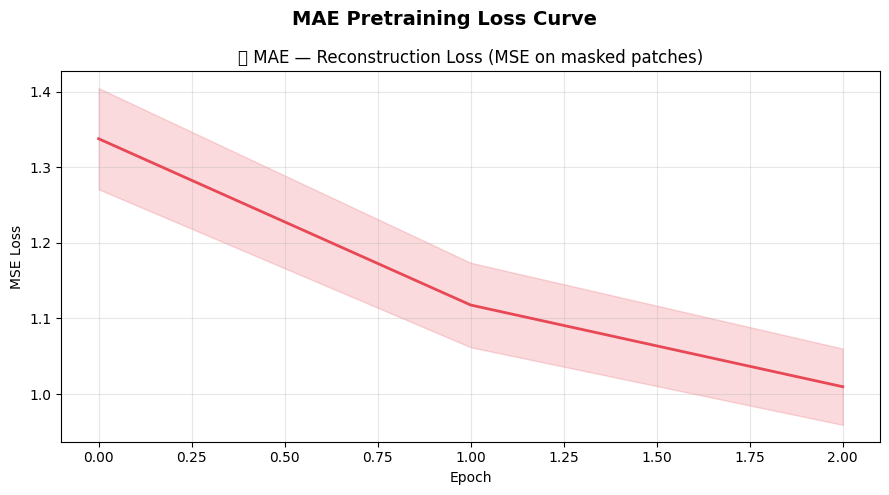

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot 1: MAE Pretraining loss curve
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('ResNet-MAE Pretraining Loss (BraTS SSL)', fontsize=14, fontweight='bold')

ax.plot(mae_losses, color='#E84855', linewidth=2)
ax.fill_between(range(len(mae_losses)),
                [l * 0.95 for l in mae_losses],
                [l * 1.05 for l in mae_losses],
                alpha=0.2, color='#E84855')
ax.set_title('🟠 ResNet-MAE — reconstruction loss on masked patches', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mae_pretrain_loss.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot A: Training curves — ResUNet vs U-Net (all label fractions)
# ─────────────────────────────────────────────────────────────────────────────

COLORS = ['#E84855', '#F4A261', '#2A9D8F', '#264653']
fracs  = finetune_cfg['training']['label_fractions']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ResUNet Fine-tune vs U-Net Baseline — Training Curves',
             fontsize=13, fontweight='bold')

def _seed42_hist(agg): return agg['per_seed'].get(42, list(agg['per_seed'].values())[0])

for frac, col in zip(fracs, COLORS):
    lbl = f'{frac:.0%}'
    rh = _seed42_hist(finetune_results[frac])
    uh = _seed42_hist(unet_results[frac])
    axes[0].plot(rh['train_loss'], color=col, lw=2,       label=f'ResUNet {lbl}')
    axes[0].plot(uh['train_loss'], color=col, lw=2, ls='--', label=f'UNet {lbl}')
    axes[1].plot(rh['val_dice'],   color=col, lw=2,       label=f'ResUNet {lbl}')
    axes[1].plot(uh['val_dice'],   color=col, lw=2, ls='--', label=f'UNet {lbl}')

for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Validation Dice Score'],
    ['Dice-CE Loss',  'Dice']):
    ax.set_title(title, fontsize=12); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resunet_vs_unet_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot B: Grouped bar chart — ResUNet vs U-Net
# ─────────────────────────────────────────────────────────────────────────────

resunet_dices = [eval_results[f]['dice']      for f in fracs]
unet_dices    = [unet_eval_results[f]['dice'] for f in fracs]

x, w = np.arange(len(fracs)), 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w/2, resunet_dices, w, label='ResUNet (BraTS ResNet-MAE SSL)', color='#2E86AB', alpha=0.88)
bars2 = ax.bar(x + w/2, unet_dices,    w, label='U-Net from Scratch',         color='#E9C46A', alpha=0.88)

def label_bars(bars, ax):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.3f}', xy=(b.get_x()+b.get_width()/2, h),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)

label_bars(bars1, ax); label_bars(bars2, ax)
ax.set_xticks(x); ax.set_xticklabels([f'{f:.0%}\nlabels' for f in fracs])
ax.set_ylabel('Mean Dice Score')
ax.set_title('ResUNet (ResNet34 Encoder) vs U-Net from Scratch — Dice by Label Fraction',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 1.1); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('resunet_vs_unet_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison plots saved.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot C: Side-by-side prediction grid — ResUNet vs U-Net
# ─────────────────────────────────────────────────────────────────────────────

# Load best SSL ResUNet for visualization (100% labels, seed 42)
seg_model = ResUNet(in_chans=1, num_classes=finetune_cfg['model']['num_classes'],
                    encoder_init='ssl', ssl_checkpoint=SSL_CHECKPOINT).to(DEVICE)
viz_ckpt = 'resunet_ssl_frac1.00_seed42.pth'
if os.path.isfile(viz_ckpt):
    seg_model.load_state_dict(torch.load(viz_ckpt, map_location=DEVICE))
seg_model.eval()
unet_ckpt = 'unet_frac1.00_seed42.pth'
if os.path.isfile(unet_ckpt):
    unet_model = UNet(in_chans=1, num_classes=finetune_cfg['model']['num_classes'],
                      base_ch=32).to(DEVICE)
    unet_model.load_state_dict(torch.load(unet_ckpt, map_location=DEVICE))
unet_model.eval()

PALETTE = np.array([[0,0,0],[255,80,80],[80,200,80],[80,80,255]], dtype=np.uint8)

def mask_to_rgb(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for c, col in enumerate(PALETTE): rgb[mask_np == c] = col
    return rgb

n_show = 4
fig, axes = plt.subplots(4, n_show, figsize=(16, 14))
fig.suptitle('Segmentation Comparison\n'
             'Row 1: Input  ·  Row 2: Ground Truth  ·  Row 3: ResUNet  ·  Row 4: U-Net',
             fontsize=12, fontweight='bold')

for row, label in enumerate(['Input MRI', 'Ground Truth', 'ResUNet', 'U-Net']):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold')

with torch.no_grad():
    for col in range(n_show):
        img_t, msk_t = val_ds[col]
        inp = img_t.unsqueeze(0).to(DEVICE)
        resunet_pred = seg_model(inp).argmax(1).squeeze().cpu().numpy()
        unet_pred    = unet_model(inp).argmax(1).squeeze().cpu().numpy()
        img_np = img_t.squeeze().numpy(); msk_np = msk_t.numpy()
        axes[0, col].imshow(img_np,                 cmap='gray')
        axes[1, col].imshow(mask_to_rgb(msk_np))
        axes[2, col].imshow(mask_to_rgb(resunet_pred))
        axes[3, col].imshow(mask_to_rgb(unet_pred))
        for row in range(4): axes[row, col].axis('off')

handles = [plt.Rectangle((0,0),1,1, color=PALETTE[i]/255.) for i in range(4)]
fig.legend(handles, ['Background','NCR (Class 1)','ED (Class 2)','ET (Class 3)'],
           loc='lower center', ncol=4, bbox_to_anchor=(0.5,-0.02), fontsize=9)
plt.tight_layout()
plt.savefig('resunet_vs_unet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Side-by-side prediction grid saved.')


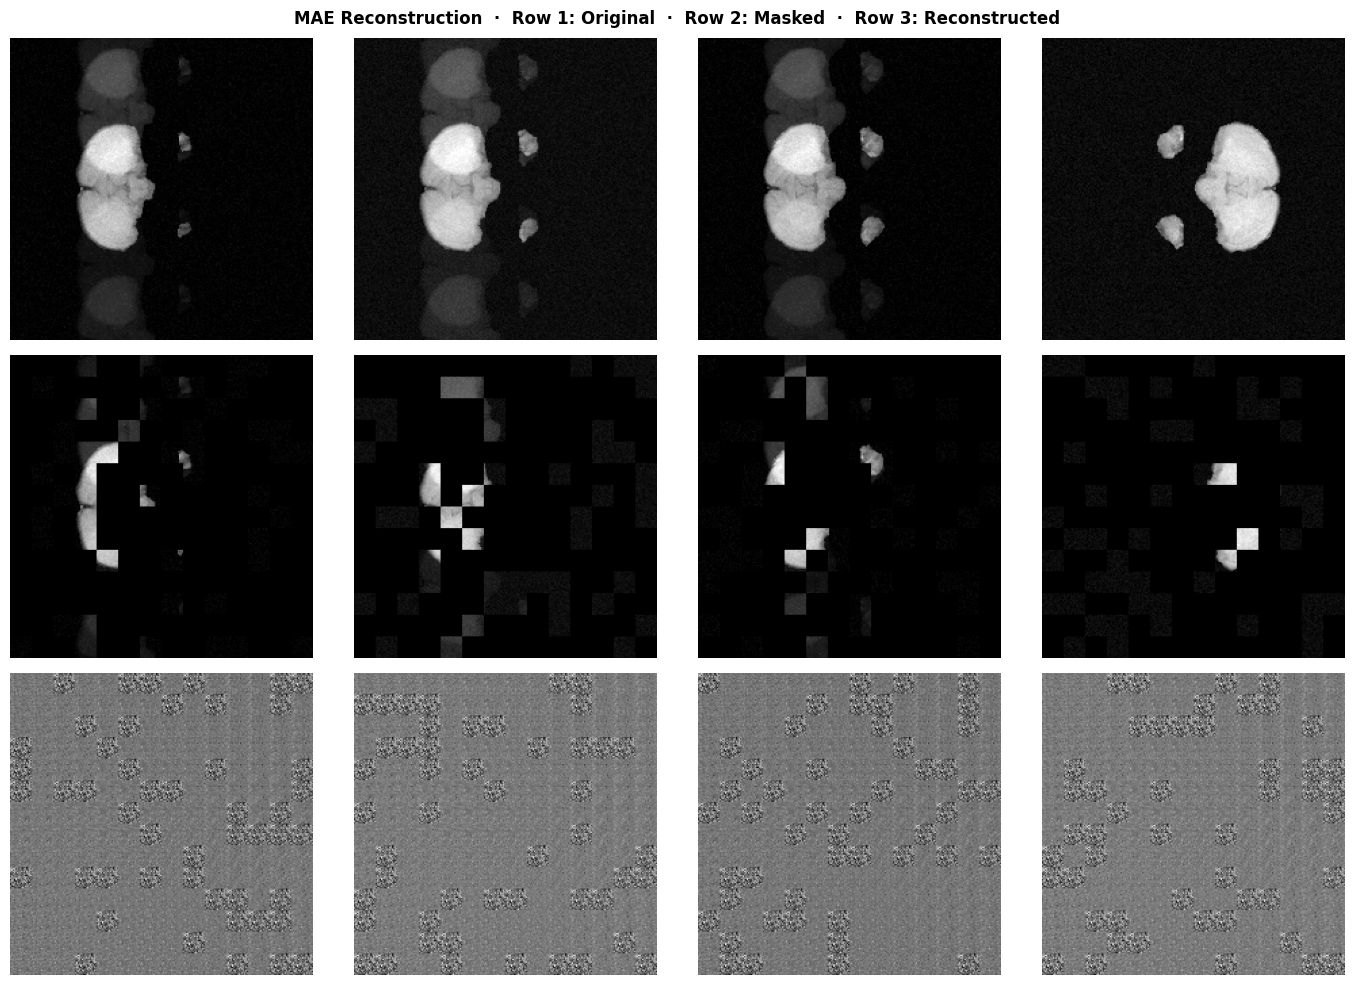

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot 5: MAE reconstruction visualisation
# ─────────────────────────────────────────────────────────────────────────────

mae_model.eval()
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('MAE Reconstruction  ·  Row 1: Original  ·  Row 2: Masked  ·  Row 3: Reconstructed',
             fontsize=12, fontweight='bold')

with torch.no_grad():
    for col in range(4):
        img_t = mae_ds[col].unsqueeze(0).to(DEVICE)
        _, pred_patches = mae_model(img_t)

        _, mask, ids_restore = mae_model.encoder(img_t, mae_model.mask_ratio)

        # Reconstruct masked input (set masked pixels to 0)
        P = mae_cfg_demo['model']['patch_size']
        img_np = img_t.squeeze().cpu().numpy()

        # Mask visualization
        patches = mae_model.patchify(img_t)           # (1,N,P*P)
        G = int(patches.size(1) ** 0.5)
        mask_img = mask[0].cpu().numpy().reshape(G, G)  # (G,G)
        mask_up  = mask_img.repeat(P, axis=0).repeat(P, axis=1)[:img_np.shape[0], :img_np.shape[1]]
        masked_np = img_np.copy()
        masked_np[mask_up.astype(bool)] = 0.

        # Reconstruct full image from decoder output
        pred_np = pred_patches[0].cpu().numpy()   # (N, P*P*C)
        pred_img = pred_np.reshape(G, G, P, P)
        # Normalize to [0,1]
        pred_img = (pred_img - pred_img.min()) / (pred_img.max() - pred_img.min() + 1e-8)
        recon_np = pred_img.transpose(0,2,1,3).reshape(G*P, G*P)[:img_np.shape[0], :img_np.shape[1]]

        axes[0, col].imshow(img_np,    cmap='gray'); axes[0, col].axis('off')
        axes[1, col].imshow(masked_np, cmap='gray'); axes[1, col].axis('off')
        axes[2, col].imshow(recon_np,  cmap='gray'); axes[2, col].axis('off')

row_labels = ['Original', f'Masked ({mae_cfg_demo["model"]["mask_ratio"]:.0%})', 'Reconstructed']
for row, rl in enumerate(row_labels):
    axes[row, 0].set_ylabel(rl, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('mae_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Final Summary Table
# ─────────────────────────────────────────────────────────────────────────────

fracs = finetune_cfg['training']['label_fractions']

print('=' * 60)
print('  FINAL RESULTS — ResNet-MAE (BraTS SSL) + ResUNet')
print('=' * 60)
print(f'  SSL:           ResNet-MAE on BraTS (mask={mae_cfg["model"]["mask_ratio"]})')
print(f'  Encoder init:  ssl → {SSL_CHECKPOINT}')
print(f'  Fine-tune:     {finetune_cfg["training"]["epochs"]} ep, '
      f'freeze encoder {finetune_cfg["training"]["freeze_encoder_epochs"]} ep')
print(f'  Few-shot seeds:{finetune_cfg["training"]["few_shot_seeds"]}')
print()
print(f'  {"Label %":>8}  {"Dice (mean±std)":>18}  {"IoU (mean±std)":>18}')
print('  ' + '-' * 50)
for frac in fracs:
    r = eval_results[frac]
    print(f'  {frac:>7.0%}  {r["dice"]:.4f}±{r.get("dice_std",0):.3f}          '
          f'{r["iou"]:.4f}±{r.get("iou_std",0):.3f}')
print('=' * 60)
print('\n✅ Pipeline complete!')
print(f'   {SSL_CHECKPOINT}  •  resunet_ssl_*.pth  •  resunet_imagenet_*.pth')
